In [1]:
import torch
import sys
from pathlib import Path

from src.model import TransformDecoder, ImageTransformPredictor
from src.dataset import ImageTransformer, TransformTokenizer
from src.dataset import DomainNetDataset, get_domainnet_dataloaders
from PIL import Image
from omegaconf import OmegaConf
from torchvision import transforms
import time
import torch.nn.functional as F
from tqdm import tqdm
import numpy as np

%load_ext autoreload
%autoreload 2

In [2]:
# !python3 -m pip install -qU ap_res_cv_is_entrypoint_protos  --index-url https://nexus.ap-team.ru/repository/pypi/simple

In [3]:
# !pip install efficientnet-pytorch

### entrypoint

docker build . -t entrypoint_itp_effnet

docker run --gpus all -p 9046:9878 --rm \
  -v /mnt/DATA2/dorin/res.cv.is.entrypoint.itp/config_effnet/config_ieee/:/config \
  -v /mnt/DATA2/dorin/weights/transformpredictor/effnet_based/:/weights \
  entrypoint_itp_effnet:latest

docker run --gpus all -p 9047:9878 --rm \
  -v /mnt/DATA2/dorin/res.cv.is.entrypoint.itp/config_effnet/config_biomedical/:/config \
  -v /mnt/DATA2/dorin/weights/transformpredictor/effnet_based/:/weights \
  entrypoint_itp_effnet:latest

docker run --gpus all -p 9048:9878 --rm \
  -v /mnt/DATA2/dorin/res.cv.is.entrypoint.itp/config_effnet/config_openaccess/:/config \
  -v /mnt/DATA2/dorin/weights/transformpredictor/effnet_based/:/weights \
  entrypoint_itp_effnet:latest

docker run --gpus all -p 9049:9878 --rm \
  -v /mnt/DATA2/dorin/res.cv.is.entrypoint.itp/config_effnet/config_apvuzring/:/config \
  -v /mnt/DATA2/dorin/weights/transformpredictor/effnet_based/:/weights \
  entrypoint_itp_effnet:latest

docker run --gpus all -p 9050:9878 --rm \
  -v /mnt/DATA2/dorin/res.cv.is.entrypoint.itp/config_effnet/config_internet/:/config \
  -v /mnt/DATA2/dorin/weights/transformpredictor/effnet_based/:/weights \
  entrypoint_itp_effnet:latest

In [2]:
1 - 1/11

0.9090909090909091

In [2]:
config = OmegaConf.load('configs/train_config_011.yaml')

preprocess = transforms.Compose([
            transforms.Resize((300, 300)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

In [3]:
model = ImageTransformPredictor(config.model)

Loaded pretrained weights for efficientnet-b3


In [4]:
# checkpoint_path = 'checkpoints/itp_011_tune/checkpoint_epoch_15.pth'
# checkpoint_path = 'checkpoints/itp_011_tune_full/checkpoint_epoch_15.pth'
# checkpoint_path = 'checkpoints/itp_011_tune_complex/checkpoint_epoch_3.pth'
# checkpoint_path = 'checkpoints/itp_effnet_tune_v2/checkpoint_epoch_7.pth'
# checkpoint_path = 'checkpoints/itp_effnet_tune_v3/checkpoint_epoch_7.pth'
checkpoint_path = 'checkpoints/itp_effnet_tune_v4/checkpoint_epoch_7.pth'

checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.to('cpu')
model.eval()
print('ready')

ready


In [5]:
# import torch
# import os

# # Пути
# checkpoint_path = 'checkpoints/itp_011_tune_full/checkpoint_epoch_15.pth'
# output_path = 'checkpoints/itp_011_tune_full/model_weights.pth'

# # Загрузка
# print(f'Loading checkpoint from {checkpoint_path}...')
# checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)

# # Инициализация модели (замените на ваш класс)
# model = ImageTransformPredictor(config.model)
# model.load_state_dict(checkpoint['model_state_dict'])
# model.eval()

# # Сохранение
# os.makedirs(os.path.dirname(output_path), exist_ok=True)
# torch.save(model.state_dict(), output_path)

# print(f'✓ Model saved to {output_path}')
# print(f'  Size: {os.path.getsize(output_path) / 1024 / 1024:.2f} MB')

In [16]:
image_path_1 = 'assets/image.jpg'
image_path_2 = 'assets/dog.jpg'

image_1 = Image.open(image_path_1)
image_2 = Image.open(image_path_2)

it = ImageTransformer()
transformed_image_1, sequence_1 = it.transform(image_1, 0.3)
print(sequence_1)
# transformed_image_1

['noop']


In [17]:
image_tensor_1 = preprocess(image_1).unsqueeze(0)
image_tensor_2 = preprocess(image_2).unsqueeze(0)
transformed_image_tensor = preprocess(transformed_image_1).unsqueeze(0)

generated = model.generate(image_tensor_1, transformed_image_tensor, max_new_tokens=10, do_sample=False)

tokenizer = TransformTokenizer()
tokens = tokenizer.decode(generated[0], skip_special_tokens=True)
print(f"Predicted: {tokens}")
print(f"Target: {sequence_1}")

Predicted: ['noop']
Target: ['noop']


In [9]:
generated

tensor([[1, 3, 2, 0, 0, 0, 0, 0, 0, 0, 0]])

In [10]:
logits = model(image_tensor_1, transformed_image_tensor, torch.tensor([[1]]))
logits = logits[0][0]
logits[:, model.pad_token_id] = -float('inf')
logits[:, model.bos_token_id] = -float('inf')
probs = torch.exp(logits) / torch.exp(logits).sum(dim=-1, keepdim=True)
p_eos = probs[:, 2]
similarities = 1.0 - p_eos
similarities.item()

0.9998735785484314

### New ui

In [5]:
from model_effnet_torch import TransformationDecoder, ImageEncoder, ImageFuser, PlagiarismDetectionModel

In [11]:
encoder = ImageEncoder()
encoder.load_state_dict(torch.load('/mnt/DATA2/dorin/weights/transformpredictor/effnet_based_contrastive_v5/image_encoder.pth'))
encoder.eval()
print('ready')

# encoder.backbone = model.image_pair_encoder.image_encoder.backbone
# state_dict = encoder.state_dict()
# torch.save(state_dict, "/mnt/DATA2/dorin/weights/transformpredictor/effnet_based_contrastive_v5/image_encoder.pth")

ready


In [12]:
fuser = ImageFuser()
fuser.load_state_dict(torch.load('/mnt/DATA2/dorin/weights/transformpredictor/effnet_based_contrastive_v5/fuser.pth'))
fuser.eval()
print('ready')

# fuser.fuser = model.image_pair_encoder.fuser
# state_dict = fuser.state_dict()
# torch.save(state_dict, "/mnt/DATA2/dorin/weights/transformpredictor/effnet_based_contrastive_v5/fuser.pth")

ready


In [13]:
decoder = TransformationDecoder()
decoder.load_state_dict(torch.load('/mnt/DATA2/dorin/weights/transformpredictor/effnet_based_contrastive_v5/decoder.pth'))
decoder.eval()
print('ready')

# state_dict = model.transform_decoder.state_dict()
# torch.save(state_dict, "/mnt/DATA2/dorin/weights/transformpredictor/effnet_based_contrastive_v5/decoder.pth")

ready


In [14]:
# import torch
# import re

# def fix_state_dict_keys(state_dict):
#     """
#     Remaps state dict keys to match current model architecture:
#     - blocks.X.attn.attn.* → blocks.X.attn.*
#     - blocks.X.cross_attn.attn.* → blocks.X.cross_attn.*
#     - blocks.X.mlp.net.* → blocks.X.net.*
#     """
#     new_state_dict = {}
#     for key, value in state_dict.items():
#         new_key = key
#         # Убираем лишний уровень attn внутри attn и cross_attn
#         new_key = re.sub(r'\.attn\.attn\.', '.attn.', new_key)
#         new_key = re.sub(r'\.cross_attn\.attn\.', '.cross_attn.', new_key)
#         # Заменяем mlp.net на net
#         new_key = re.sub(r'\.mlp\.net\.', '.net.', new_key)
#         new_state_dict[new_key] = value
#     return new_state_dict

# # Загрузка и исправление
# decoder = TransformationDecoder()
# raw_state_dict = torch.load('/mnt/DATA2/dorin/weights/transformpredictor/effnet_based_contrastive_v5/decoder.pth', map_location='cpu')
# fixed_state_dict = fix_state_dict_keys(raw_state_dict)

# # Проверка (опционально)
# missing = set(decoder.state_dict().keys()) - set(fixed_state_dict.keys())
# unexpected = set(fixed_state_dict.keys()) - set(decoder.state_dict().keys())
# if missing:
#     print(f"Still missing: {missing}")
# if unexpected:
#     print(f"Still unexpected: {unexpected}")

# # Загрузка
# decoder.load_state_dict(fixed_state_dict, strict=True)
# decoder.eval()
# print('ready')

# torch.save(fixed_state_dict, "/mnt/DATA2/dorin/weights/transformpredictor/effnet_based_contrastive_v5/decoder.pth")

In [18]:
embs1, embs2 = encoder(image_tensor_1), encoder(transformed_image_tensor)
fused = fuser(embs1, embs2)

logits = decoder(fused, torch.tensor([[1]]))
logits[:, decoder.pad_token_id] = -float('inf')
logits[:, decoder.bos_token_id] = -float('inf')
probs = F.softmax(logits, dim=-1)  # Стабильная реализация
p_eos = probs[:, 2]
similarities = 1.0 - p_eos
similarities.item()

0.9998735785484314

In [19]:
fused.shape

torch.Size([1, 1, 512])

In [19]:
full_model = PlagiarismDetectionModel()

full_model.load_components('/mnt/DATA2/dorin/weights/transformpredictor/effnet_based_contrastive_v4/image_encoder.pth',
                                         '/mnt/DATA2/dorin/weights/transformpredictor/effnet_based_contrastive_v4/fuser.pth',
                                         '/mnt/DATA2/dorin/weights/transformpredictor/effnet_based_contrastive_v4/decoder.pth'
                                          )

full_model.to('cuda').eval()
print('ok')

ok


In [20]:
full_model.compute_similarities_batch([transformed_image_1], [[image_1]])

[[0.9999341368675232]]

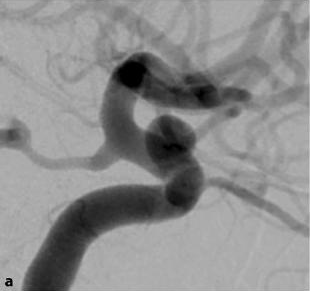

In [17]:
from ap_res_cv_is_entrypoint_protos.client import Client as EntrypointClient
from ap_res_cv_is_searchengine_protos.client import Client as SearchEngineClient, SearchEngineClientAsync
import io
from PIL import Image

client_searchengine = SearchEngineClientAsync('https://searchengine-openaccess-imagesearch.internal.k8s.antiplagiat.ru/')
se_info = await client_searchengine.get_image('3b76364f-12ff-30cb-ec0d-e2009e530804', image=True, meta=False)
byte_image = se_info['Image']
image = Image.open(io.BytesIO(byte_image))
image.show()

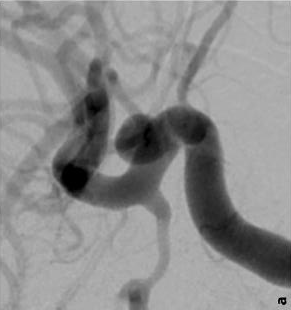

In [18]:
image_rot_90 = image.rotate(90, expand=True)
image_rot_90

In [46]:
full_model(image_tensor_1, transformed_image_tensor).item()

0.999548077583313

In [19]:
image1 = Image.open('/mnt/DATA/dorin/qualitytest/output_effnet/source_images_IEEE/with_rubricators_filtered/0286fd02-ab61-4ea2-a68d-a9d129ef765f/39_1/request.png')
image2 = Image.open('/mnt/DATA/dorin/qualitytest/output_effnet/source_images_IEEE/with_rubricators_filtered/0286fd02-ab61-4ea2-a68d-a9d129ef765f/39_1/source_3cdc3ca7-a3bf-00af-32f8-723e3589c11b.jpeg')

In [33]:
# !python3 -m pip install -qU ap_res_cv_is_entrypoint_protos  --index-url https://nexus.ap-team.ru/repository/pypi/simple
# !python3 -m pip install -qU ap_res_cv_is_searchengine_protos  --index-url https://nexus.ap-team.ru/repository/pypi/simple
from ap_res_cv_is_entrypoint_protos.client import Client as EntrypointClient
from ap_res_cv_is_searchengine_protos.client import Client as SearchEngineClient, SearchEngineClientAsync
import io

stub_entrypoint = EntrypointClient(['ipv4://192.168.20.73:9050'])
client_searchengine = SearchEngineClientAsync('https://searchengine-internet-v2-imagesearch.internal.k8s.antiplagiat.ru/')

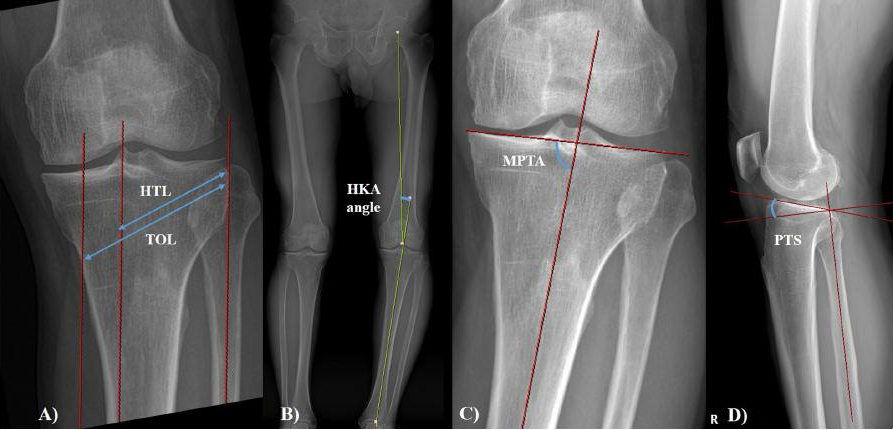

In [34]:
client_searchengine = SearchEngineClientAsync('https://searchengine-openaccess-imagesearch.internal.k8s.antiplagiat.ru/')
se_info = await client_searchengine.get_image('2a85f355-3a95-6499-79a0-88c101a45337', image=True, meta=False)
byte_image = se_info['Image']
image = Image.open(io.BytesIO(byte_image))
image.show()

In [4]:
image_rotated = image.rotate(180, expand=True)

buffer = io.BytesIO()
image_rotated.save(buffer, format='PNG', quality=100, subsampling=0)  # Макс. качество
byte_image_rotated = buffer.getvalue()

In [5]:
ep_result = stub_entrypoint.check_image(byte_image_rotated, 'test', '1')
ep_result

{'Sources': [{'SrcId': 'fe7d8ab7-e58a-e4ea-ca1e-fab7f64510b2',
   'MatchProb': 0.9999292,
   'Metadata': {'DocId': '15de01c0-f8a5-4863-af8e-d28e0f3c6158',
    'PageNumber': 4,
    'Type': 'General',
    'Tags': ''},
   'SourceMetaData': {'DocInfo': [{'Uuid': '15de01c0-f8a5-4863-af8e-d28e0f3c6158',
      'PageNumber': 4,
      'Tags': []},
     {'Uuid': '8da0df9d-c7f6-4c44-9cf7-0ad4c52de502',
      'PageNumber': 4,
      'Tags': []}],
    'Tags': '',
    'Type': 'General'},
   'Type': 'Plagiarism'}],
 'RequestId': 'test',
 'Originality': 0.0}

In [24]:
full_model.compute_similarities_batch([image1], [[image2]])

[[0.0018579959869384766]]

In [6]:
# ep_result = stub_entrypoint.check_image(byte_image, 'test', '1')